In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("RetailIQ Customer Analysis started!")

RetailIQ Customer Analysis started!


In [15]:
# Load cleaned dataset

file_path = "../data/processed/clean_sales_data.csv"

customer_df = pd.read_csv(file_path)

customer_df["InvoiceDate"] = pd.to_datetime(customer_df["InvoiceDate"])

print("Clean dataset loaded successfully!")
print("Rows:", len(customer_df))

Clean dataset loaded successfully!
Rows: 392692


In [16]:
# ===== BASIC CUSTOMER ANALYSIS =====

customer_summary = (
    customer_df
    .groupby("CustomerID")
    .agg(
        TotalOrders=("InvoiceNo", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        TotalRevenue=("Revenue", "sum")
    )
    .reset_index()
)

print("Customer summary created successfully!")
print("Number of customers:", len(customer_summary))

display(customer_summary.head(10))

Customer summary created successfully!
Number of customers: 4338


,CustomerID,TotalOrders,TotalQuantity,TotalRevenue
0,12346.0,1,74215,77183.60
1,12347.0,7,2458,4310.00
2,12348.0,4,2341,1797.24
3,12349.0,1,631,1757.55
4,12350.0,1,197,334.40
5,12352.0,8,536,2506.04
6,12353.0,1,20,89.00
7,12354.0,1,530,1079.40
8,12355.0,1,240,459.40
9,12356.0,3,1591,2811.43


In [17]:
# ===== TOP CUSTOMERS BY REVENUE =====

top_customers = (
    customer_summary
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
)

display(top_customers)

,CustomerID,TotalOrders,TotalQuantity,TotalRevenue
1689,14646.0,73,196915,280206.02
4201,18102.0,60,64124,259657.30
3728,17450.0,46,69973,194390.79
3008,16446.0,2,80997,168472.50
1879,14911.0,201,80240,143711.17
55,12415.0,21,77374,124914.53
1333,14156.0,55,57768,117210.08
3771,17511.0,31,64549,91062.38
2702,16029.0,63,40108,80850.84
0,12346.0,1,74215,77183.60


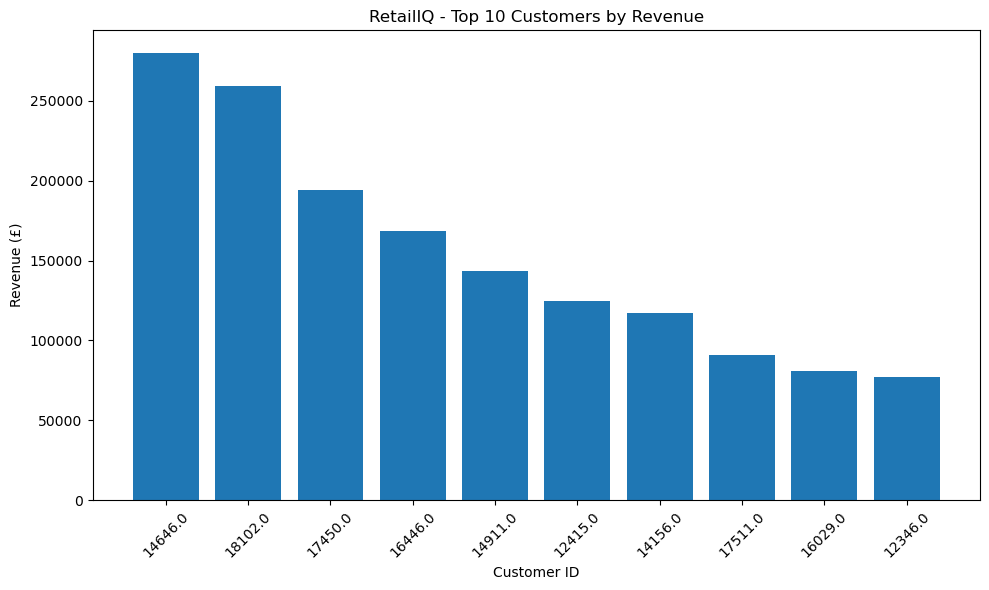

In [18]:
# ===== TOP 10 CUSTOMERS BY REVENUE =====

plt.figure(figsize=(10, 6))

plt.bar(
    top_customers["CustomerID"].astype(str),
    top_customers["TotalRevenue"]
)

plt.title("RetailIQ - Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

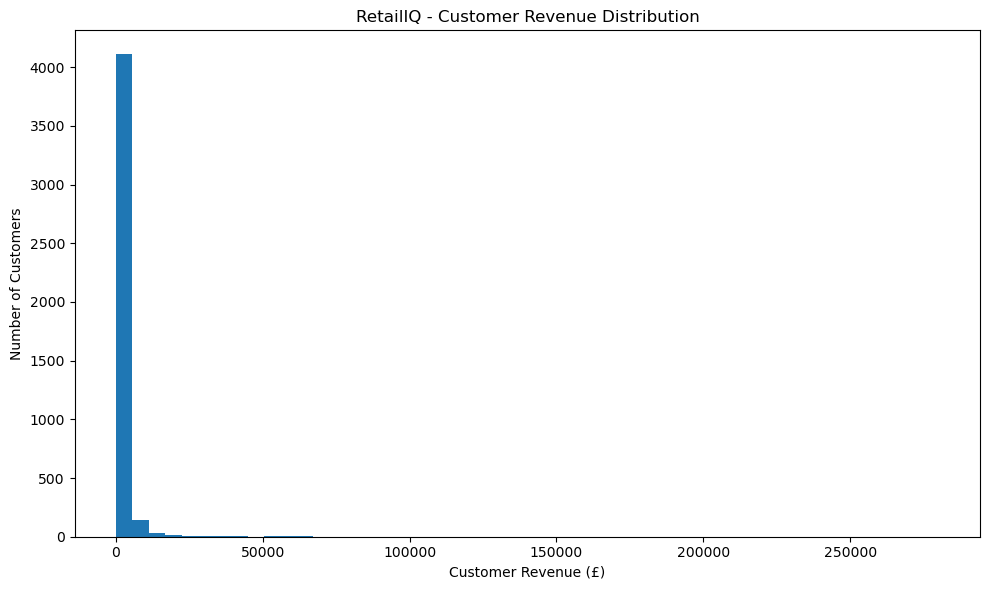

In [19]:
# ===== CUSTOMER REVENUE DISTRIBUTION =====

plt.figure(figsize=(10, 6))

plt.hist(
    customer_summary["TotalRevenue"],
    bins=50
)

plt.title("RetailIQ - Customer Revenue Distribution")
plt.xlabel("Customer Revenue (£)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [20]:
# ===== CUSTOMER KPIs =====

average_customer_revenue = customer_summary["TotalRevenue"].mean()
median_customer_revenue = customer_summary["TotalRevenue"].median()
average_orders_per_customer = customer_summary["TotalOrders"].mean()

print("===== RETAILIQ CUSTOMER KPIs =====")
print(f"Total Customers: {len(customer_summary):,}")
print(f"Average Customer Revenue: £{average_customer_revenue:,.2f}")
print(f"Median Customer Revenue: £{median_customer_revenue:,.2f}")
print(f"Average Orders per Customer: {average_orders_per_customer:.2f}")


===== RETAILIQ CUSTOMER KPIs =====
Total Customers: 4,338
Average Customer Revenue: £2,048.69
Median Customer Revenue: £668.57
Average Orders per Customer: 4.27


In [21]:
# ===== RFM ANALYSIS DATE =====

analysis_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2011-12-10 12:50:00


In [22]:
# ===== CALCULATE RFM VALUES =====

rfm = (
    customer_df
    .groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

print("RFM analysis created successfully!")

display(rfm.head(10))

RFM analysis created successfully!


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [23]:
# ===== RFM STATISTICS =====

print("===== RFM STATISTICS =====")

display(rfm[[
    "Recency",
    "Frequency",
    "Monetary"
]].describe())

===== RFM STATISTICS =====


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [24]:
# ===== RFM SCORING =====

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

print("RFM scores created successfully!")

display(rfm.head(10))

RFM scores created successfully!


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,326,1,77183.60,1,1,5
1,12347.0,2,7,4310.00,5,5,5
2,12348.0,75,4,1797.24,2,4,4
3,12349.0,19,1,1757.55,4,1,4
4,12350.0,310,1,334.40,1,1,2
5,12352.0,36,8,2506.04,3,5,5
6,12353.0,204,1,89.00,1,1,1
7,12354.0,232,1,1079.40,1,1,4
8,12355.0,214,1,459.40,1,1,2
9,12356.0,23,3,2811.43,4,3,5


In [25]:
# ===== OVERALL RFM SCORE =====

rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

print("RFM score range:",
      rfm["RFM_Score"].min(),
      "to",
      rfm["RFM_Score"].max())

display(
    rfm.sort_values(
        "RFM_Score",
        ascending=False
    ).head(10)
)

RFM score range: 3 to 15


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
1430,14292.0,8,9,4871.93,5,5,5,15
3342,16904.0,4,16,3653.75,5,5,5,15
445,12921.0,9,37,16587.09,5,5,5,15
2349,15544.0,9,9,3546.71,5,5,5,15
4074,17924.0,12,7,2962.50,5,5,5,15
2351,15547.0,7,14,4910.60,5,5,5,15
1754,14735.0,4,32,6065.69,5,5,5,15
1752,14732.0,8,8,2702.49,5,5,5,15
431,12901.0,9,28,17654.54,5,5,5,15
2358,15555.0,12,16,4794.86,5,5,5,15


In [26]:
# ===== CUSTOMER SEGMENTATION =====

def segment_customer(score):
    if score >= 13:
        return "VIP"
    elif score >= 10:
        return "Loyal"
    elif score >= 7:
        return "Regular"
    elif score >= 5:
        return "At Risk"
    else:
        return "Low Value"


rfm["Segment"] = rfm["RFM_Score"].apply(segment_customer)

print("Customer segmentation completed!")

display(
    rfm["Segment"].value_counts().to_frame("Customers")
)

Customer segmentation completed!


,Customers
Segment,
Regular,1088
Loyal,1010
VIP,933
At Risk,763
Low Value,544


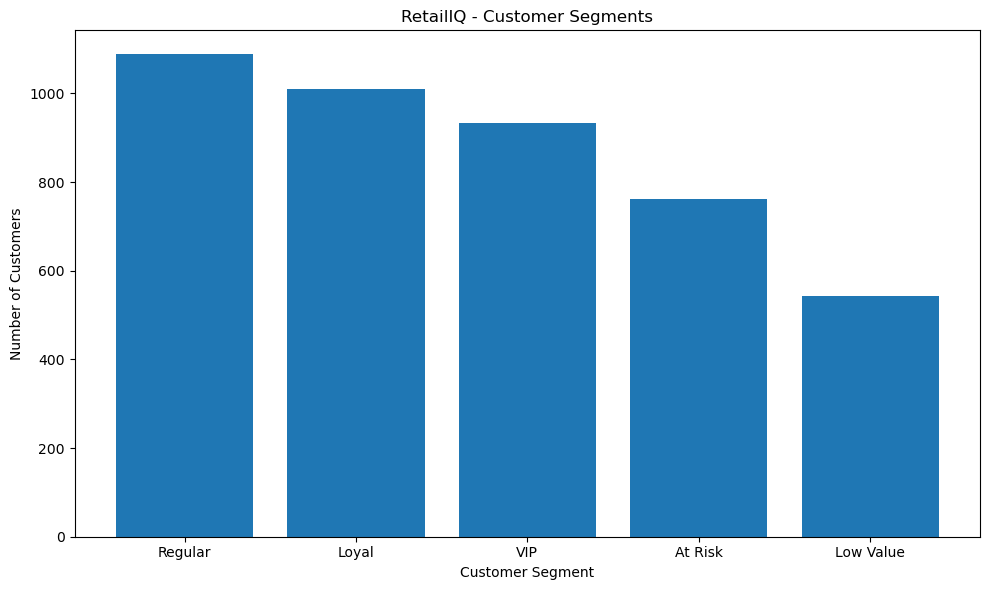

In [27]:
# ===== CUSTOMER SEGMENT DISTRIBUTION =====

segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("RetailIQ - Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [28]:
# ===== SAVE RFM CUSTOMER DATA =====

rfm.to_csv(
    "../data/processed/rfm_customer_segments.csv",
    index=False
)

print("RFM customer segmentation saved successfully!")

RFM customer segmentation saved successfully!


In [29]:
# ===== RFM SEGMENT SUMMARY =====

segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        TotalRevenue=("Monetary", "sum"),
        AverageRevenue=("Monetary", "mean"),
        AverageFrequency=("Frequency", "mean"),
        AverageRecency=("Recency", "mean")
    )
    .sort_values("TotalRevenue", ascending=False)
    .reset_index()
)

display(segment_summary)

,Segment,Customers,TotalRevenue,AverageRevenue,AverageFrequency,AverageRecency
0,VIP,933,6241545.770,6689.759668,11.752412,14.639871
1,Loyal,1010,1403001.631,1389.110526,3.857426,43.406931
2,Regular,1088,878035.712,807.018118,2.009191,85.531250
3,At Risk,763,260496.231,341.410526,1.226737,147.342071
4,Low Value,544,104129.550,191.414614,1.009191,254.490809


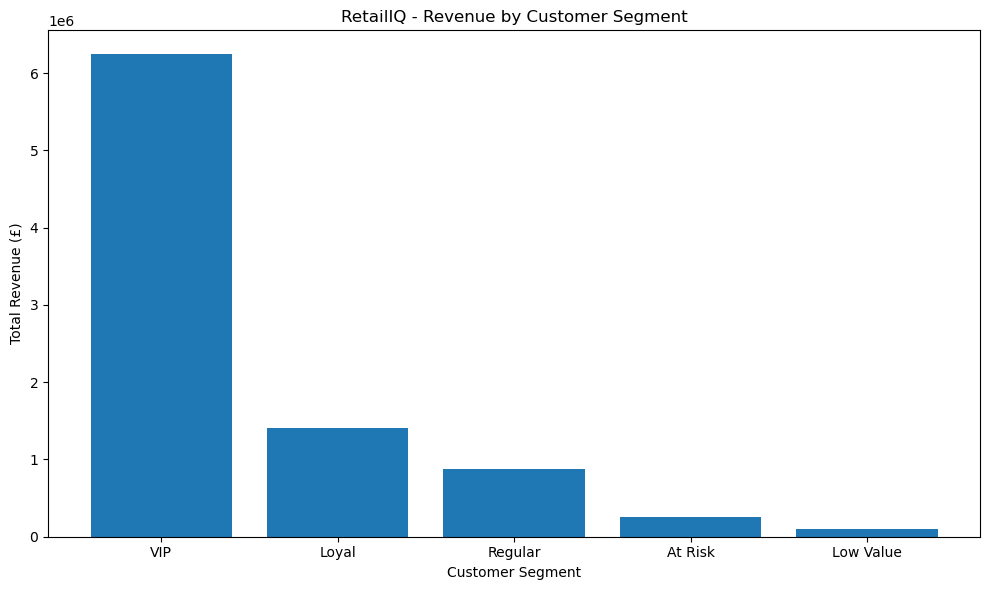

In [30]:
# ===== REVENUE BY CUSTOMER SEGMENT =====

plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary["Segment"],
    segment_summary["TotalRevenue"]
)

plt.title("RetailIQ - Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (£)")

plt.tight_layout()
plt.show()

In [31]:
# ===== SAVE SEGMENT SUMMARY =====

segment_summary.to_csv(
    "../data/processed/customer_segment_summary.csv",
    index=False
)

print("Customer segment summary saved successfully!")

Customer segment summary saved successfully!
